# Predictive Maintenance Failure Classification

This notebook prepares machine sensor data, engineers mechanical power, handles class imbalance, tunes SVM classifiers, and evaluates failure-type predictions.

In [23]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbalancedPipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC


## 1. Load and inspect the data

In [12]:
df = pd.read_csv(
    r"C:\Users\olahi\Desktop\Linear regression\Predictive Maintenance of Machines\data\cleaned_data.csv"
)


In [13]:
df.head()

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Vibration Levels,Operational Hours,Failure Type,Power [kW]
0,M14860,M,298.1,308.6,1551,42.8,42.0,20.0,No Failure,6.951591
1,L47181,L,298.2,308.7,1408,46.3,52.0,21.0,No Failure,6.826723
2,L47182,L,298.1,308.5,1498,49.4,44.0,18.0,No Failure,7.749388
3,L47183,L,298.2,308.6,1433,39.5,52.0,10.0,No Failure,5.927505
4,L47184,L,298.2,308.7,1408,40.0,44.0,10.0,No Failure,5.897817


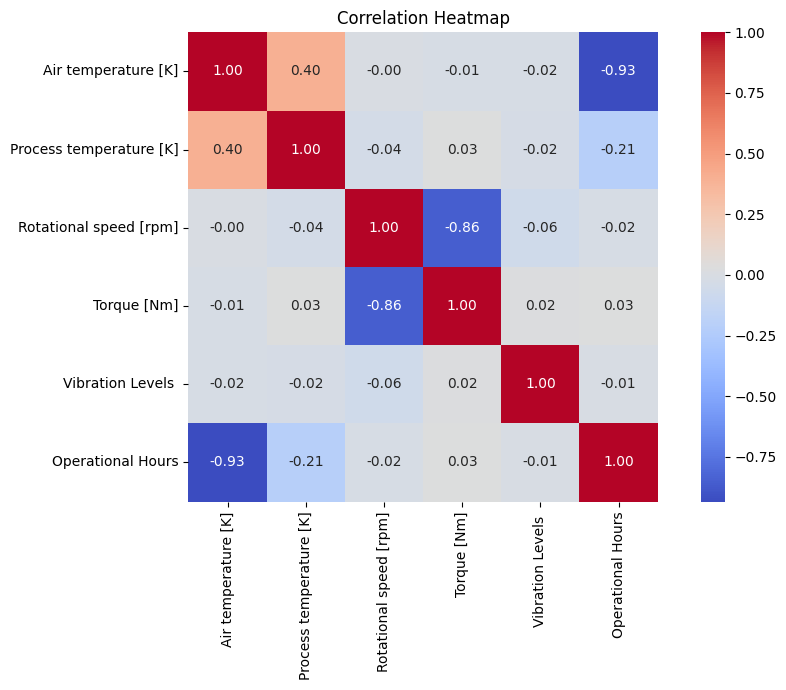

In [7]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 2. Feature engineering and preprocessing

Mechanical power is calculated from torque and rotational speed. Numeric features are imputed and standardized; the machine type is imputed and one-hot encoded.

In [14]:
target_column = "Failure Type"

# Mechanical power = torque x angular velocity.
df["Power [kW]"] = (
    df["Torque [Nm]"] * 2 * np.pi * df["Rotational speed [rpm]"] / 60 / 1000
)

base_feature_columns = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Vibration Levels ",
    "Operational Hours",
]

feature_columns = base_feature_columns + ["Power [kW]"]

X = df[feature_columns]
y = df[target_column]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_preprocessing = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_preprocessing = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessing, numeric_features),
        ("categorical", categorical_preprocessing, categorical_features),
    ]
)

preprocessing_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor)]
)

print(f"Power range: {df['Power [kW]'].min():.2f} to {df['Power [kW]'].max():.2f} kW")
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")


Power range: 1.26 to 9.70 kW
Numeric features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Vibration Levels ', 'Operational Hours', 'Power [kW]']
Categorical features: ['Type']


In [15]:
df.to_csv(
    r"C:\Users\olahi\Desktop\Linear regression\Predictive Maintenance of Machines\data\cleaned_data.csv",
    index=False,
)
print("Saved cleaned_data.csv with the Power [kW] feature.")


Saved cleaned_data.csv with the Power [kW] feature.


## 3. Stratified train-test split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 400
Testing samples: 100


## 4. Tune imbalance-aware classifiers

Oversampling is applied only to training folds. Grid search selects SVM hyperparameters using macro F1.

In [21]:
failure_label = "No Failure"
y_train_binary = (y_train != failure_label).astype(int)
y_test_binary = (y_test != failure_label).astype(int)

svm_parameters = {
    "classifier__C": [0.1, 1, 10],
    "classifier__gamma": ["scale", 0.01, 0.1],
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

stage1_pipeline = ImbalancedPipeline(
    steps=[
        ("preprocessing", clone(preprocessor)),
        ("oversampling", RandomOverSampler(random_state=42)),
        ("classifier", SVC(kernel="rbf")),
    ]
)
stage1_search = GridSearchCV(
    stage1_pipeline,
    param_grid=svm_parameters,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)
stage1_search.fit(X_train, y_train_binary)
stage1_prediction = stage1_search.predict(X_test)

failure_train_mask = y_train != failure_label
X_train_failures = X_train.loc[failure_train_mask]
y_train_failures = y_train.loc[failure_train_mask]

stage2_pipeline = ImbalancedPipeline(
    steps=[
        ("preprocessing", clone(preprocessor)),
        ("oversampling", RandomOverSampler(random_state=42)),
        ("classifier", SVC(kernel="rbf")),
    ]
)
stage2_search = GridSearchCV(
    stage2_pipeline,
    param_grid=svm_parameters,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
)
stage2_search.fit(X_train_failures, y_train_failures)

two_stage_prediction = pd.Series(failure_label, index=X_test.index, dtype="object")
predicted_failure_mask = stage1_prediction == 1
if predicted_failure_mask.any():
    two_stage_prediction.loc[predicted_failure_mask] = stage2_search.predict(
        X_test.loc[predicted_failure_mask]
    )
two_stage_prediction = two_stage_prediction.to_numpy()

direct_pipeline = ImbalancedPipeline(
    steps=[
        ("preprocessing", clone(preprocessor)),
        ("oversampling", RandomOverSampler(random_state=42)),
        ("classifier", SVC(kernel="rbf")),
    ]
)
direct_search = GridSearchCV(
    direct_pipeline,
    param_grid=svm_parameters,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
)
direct_search.fit(X_train, y_train)
direct_prediction = direct_search.predict(X_test)

strategy_predictions = {
    "Two-stage SVM": two_stage_prediction,
    "Direct multiclass SVM": direct_prediction,
}
strategy_results = []
for strategy_name, strategy_prediction in strategy_predictions.items():
    strategy_results.append(
        {
            "Strategy": strategy_name,
            "Accuracy": accuracy_score(y_test, strategy_prediction),
            "Balanced accuracy": balanced_accuracy_score(y_test, strategy_prediction),
            "Macro F1": f1_score(
                y_test,
                strategy_prediction,
                average="macro",
                zero_division=0,
            ),
            "Failure recall": recall_score(
                y_test_binary,
                (strategy_prediction != failure_label).astype(int),
                zero_division=0,
            ),
        }
    )

comparison = pd.DataFrame(strategy_results).sort_values(
    by="Macro F1", ascending=False
)
display(comparison)

best_strategy = comparison.iloc[0]["Strategy"]
y_pred = strategy_predictions[best_strategy]
training_pipeline = (
    {"stage1": stage1_search.best_estimator_, "stage2": stage2_search.best_estimator_}
    if best_strategy == "Two-stage SVM"
    else direct_search.best_estimator_
)

print(f"Selected strategy: {best_strategy}")
print(f"Stage 1 best parameters: {stage1_search.best_params_}")
print(f"Stage 2 best parameters: {stage2_search.best_params_}")
print("\nFailure type classification report:")
print(classification_report(y_test, y_pred, zero_division=0))


,Strategy,Accuracy,Balanced accuracy,Macro F1,Failure recall
1,Direct multiclass SVM,0.77,0.511425,0.335602,0.714286
0,Two-stage SVM,0.81,0.399866,0.321378,0.285714


Selected strategy: Direct multiclass SVM
Stage 1 best parameters: {'classifier__C': 10, 'classifier__gamma': 'scale'}
Stage 2 best parameters: {'classifier__C': 0.1, 'classifier__gamma': 0.1}

Failure type classification report:
                    precision    recall  f1-score   support

        No Failure       0.97      0.80      0.88        93
Overstrain Failure       0.20      1.00      0.33         2
     Power Failure       0.00      0.00      0.00         1
 Tool Wear Failure       0.09      0.25      0.13         4

          accuracy                           0.77       100
         macro avg       0.32      0.51      0.34       100
      weighted avg       0.91      0.77      0.83       100



In [24]:
model_path = (
    r"C:\Users\olahi\Desktop\Linear regression\Predictive Maintenance of Machines\model\failure_type_model.joblib"
)
joblib.dump(training_pipeline, model_path)
print(f"Saved trained model to: {model_path}")


Saved trained model to: C:\Users\olahi\Desktop\Linear regression\Predictive Maintenance of Machines\model\failure_type_model.joblib


## 5. Evaluate the selected strategy

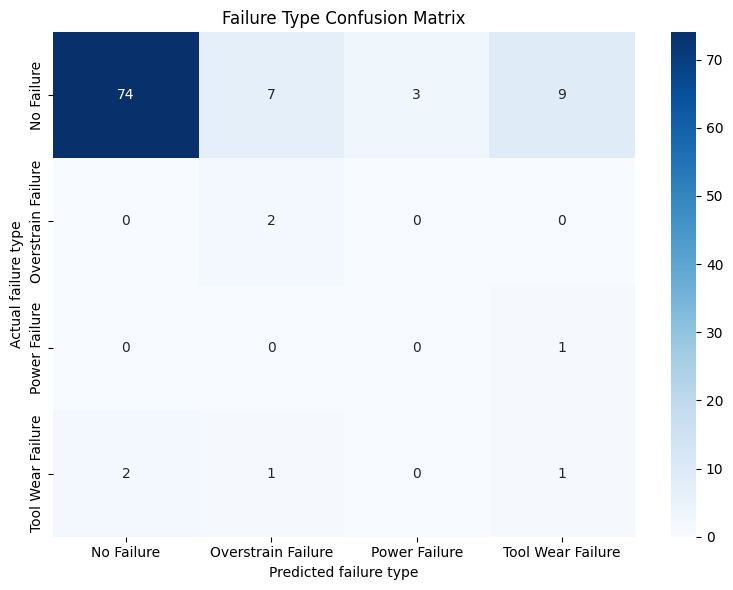

In [20]:
labels = np.unique(y)
confusion = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Predicted failure type")
plt.ylabel("Actual failure type")
plt.title("Failure Type Confusion Matrix")
plt.tight_layout()
plt.show()
